<h1><center> Praktikum Text Mining: Plagiarism Detection </center></h1>
<h2><center> Dosen Pengampu Dr Tita Karlita S.Kom., M.Kom </center></h2>


<img src="logo pens.png" 
        alt="Picture" 
        width="380" 
        height="380" 
        style="display: block; margin: 0 auto" />

<h3><center>Wahyu Ikbal Maulana</center></h3>

<h3><center>3323600056</center></h3>

<h3><center>D4 SDT B</center></h3>

<h1><center>Politeknik Elektronika Negeri Surabaya</center></h1>




## <b><span style='color:#FA5E3C'>|</span> Analisa </b> 

In [16]:
import pandas as pd
from PyPDF2 import PdfReader
from tqdm import tqdm

def extract_text_from_pdf(pdf_path):
    # Open the PDF
    document = PdfReader(pdf_path)
    text_data = []
    
    # Loop through each page and extract text
    for page_num in tqdm(range(len(document.pages)), desc="Extracting text from PDF"):
        page = document.pages[page_num]
        text = page.extract_text()  # Extract text
        text_data.append({"page_number": page_num + 1, "text": text})
    
    return pd.DataFrame(text_data)

def preprocess_data(pdf_path):
    # Extract text from the PDF and load into a dataframe
    data = extract_text_from_pdf(pdf_path)
    # Drop empty rows (pages without text)
    data = data.dropna(subset=['text']).reset_index(drop=True)
    return data

# Read data & preprocess it
data_path = "D:/A-Curated-List-Of-Data-Science-Project-of-PoIiteknik-Elektronika-Negeri-Surabaya/Archive semester 2/3323600056_Wahyu Ikbal Maulana_Discriminant Analysis 2.pdf"
source_data = preprocess_data(data_path)

# Display the first few rows of extracted text
print(source_data.head())

Extracting text from PDF: 100%|██████████| 7/7 [00:00<00:00, 34.53it/s]

   page_number                                               text
0            1  Percobaan ke-2: Studi Kasus 2\nlibrary(DT)    ...
1            2  $multiv ariateNor mality A data.frame: 1 × 4\n...
2            3  lurus 'chi-square qq-plot'.\nboxM(data = data[...
3            4  library(dplyr)\n#Hitung vektor rata-rata untuk...
4            5  The Kernel crashed while executing code in the...


In [17]:
source_data

,page_number,text
0,1,Percobaan ke-2: Studi Kasus 2\nlibrary(DT) ...
1,2,$multiv ariateNor mality A data.frame: 1 × 4\n...
2,3,lurus 'chi-square qq-plot'.\nboxM(data = data[...
3,4,library(dplyr)\n#Hitung vektor rata-rata untuk...
4,5,The Kernel crashed while executing code in the...
5,6,cb0\ncb1\n#Linear Score Function untuk species...
6,7,"unggul dengan tingkat akurasi mencapai 0,97 (j..."


<div style="border-radius: 10px; border: #0ea5e9 solid; padding: 15px; background-color: #ffffff00; font-size: 100%; text-align: left;">
    <b>🖊️ Langkah pertama :</b>

Untuk mengatasi limitasi dari model BERT supaya dapat memberikan koonteks dan informasi yang spesifik disini kita perlu

- create_vector_from_text: Menghasilkan vector yang mempresentasikan satu dokomen/laprak
- create_vector_index:  Menghasilkan index yang merepresentasikan vector dokumen
</div>

## <b><span style='color:#FA5E3C'>|</span> A BERT model </b> 
Untuk mengatasi limitasi dari model BERT supaya dapat memberikan konteks dan informasi yang spesifik disini kita perlu

- create_vector_from_text: Menghasilkan vector yang mempresentasikan satu dokomen/laprak
- create_vector_index:  Menghasilkan index yang merepresentasikan vector dokumen

In [18]:
# Useful libraries
import numpy as np
import torch
from keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer,  AutoModelForSequenceClassification
from sklearn.metrics.pairwise import cosine_similarity

# Load bert model
model_path = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_path,
                                         do_lower_case=True)
model = AutoModelForSequenceClassification.from_pretrained(model_path,
                                                         output_attentions=False,
                                                         output_hidden_states=True)
                                                        
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
 
def create_vector_from_text(tokenizer, model, text, MAX_LEN = 510):
  
    input_ids = tokenizer.encode(
                        text,
                        add_special_tokens = True,
                        max_length = MAX_LEN,                          
    )   
    results = pad_sequences([input_ids], maxlen=MAX_LEN, dtype="long",
                              truncating="post", padding="post")
    # Remove the outer list.
    input_ids = results[0]
    # Create attention masks   
    attention_mask = [int(i>0) for i in input_ids]
    # Convert to tensors.
    input_ids = torch.tensor(input_ids)
    attention_mask = torch.tensor(attention_mask)
    # Add an extra dimension for the "batch" (even though there is only one
    # input in this batch.)
    input_ids = input_ids.unsqueeze(0)
    attention_mask = attention_mask.unsqueeze(0)
    # Put the model in "evaluation" mode, meaning feed-forward operation.
    model.eval()
    # Run the text through BERT, and collect all of the hidden states produced
    # from all 12 layers.
    with torch.no_grad():       
        logits, encoded_layers = model(
                                    input_ids = input_ids,
                                    token_type_ids = None,
                                    attention_mask = attention_mask,
                                    return_dict=False)

    layer_i = 12 # The last BERT layer before the classifier.
    batch_i = 0 # Only one input in the batch.
    token_i = 0 # The first token, corresponding to [CLS]
    
    # Extract the vector.
    vector = encoded_layers[layer_i][batch_i][token_i]
    # Move to the CPU and convert to numpy ndarray.
    vector = vector.detach().cpu().numpy()
    return(vector)

def create_vector_index(data):
  
   # The list of all the vectors
   vectors = []
  
   # Get overall text data
   source_data = data.abstract.values
  
   # Loop over all the comment and get the embeddings
   for text in tqdm(source_data):
      
       # Get the embedding
       vector = create_vector_from_text(tokenizer, model, text)
      
       #add it to the list
       vectors.append(vector)
  
   data["vectors"] = vectors
   data["vectors"] = data["vectors"].apply(lambda emb: np.array(emb))
   data["vectors"] = data["vectors"].apply(lambda emb: emb.reshape(1, -1))
   return data
# Create the vector index
vector_index = create_vector_index(source_data)
vector_index.sample(5)

ModuleNotFoundError: No module named 'numpy.char'

## <b><span style='color:#FA5E3C'>|</span> Analisis plagiarism </b> 
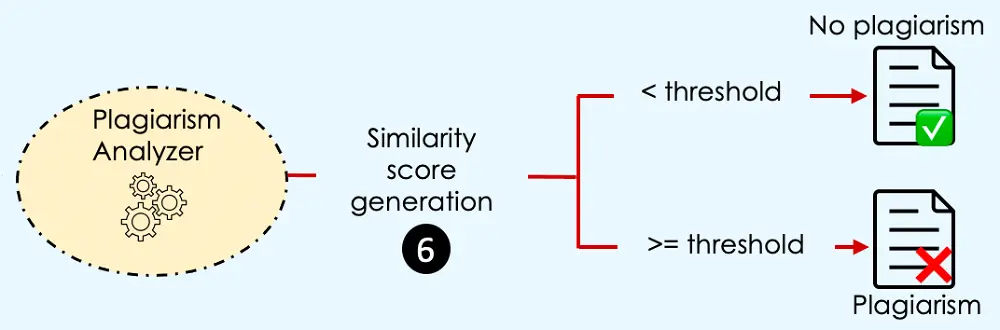

- similarity_score: Skor kemiripan antara dokumen satu dengan dokumen lainnnya 
- is_plagiarism: Hasil plagiarisme ketika kemiripannya melebihi dari nilai threshold.
- most_similar_article: Tekstual informasi yang mirip dengan dokumen
- article_submitted: Dokumen yang telah disubmit

In [ ]:
def process_document(text):
  """
  Create a vector for given text and adjust it for cosine similarity search
  """
  text_vect = create_vector_from_text(tokenizer, model, text)
  text_vect = np.array(text_vect)
  text_vect = text_vect.reshape(1, -1)
  return text_vect

def is_plagiarism(similarity_score, plagiarism_threshold):
  is_plagiarism = False
  if(similarity_score >= plagiarism_threshold):
      is_plagiarism = True
  return is_plagiarism

def check_incoming_document(incoming_document):
  text_lang = detect(incoming_document)
  language_list = ['de', 'fr', 'el', 'ja', 'ru']
  final_result = ""
  if(text_lang == 'en'):
    final_result = incoming_document
  elif(text_lang not in language_list):
    final_result = None
  else:
    # Translate in English
    final_result = translate_text(incoming_document, text_lang)
  return final_result
 
def run_plagiarism_analysis(query_text, data, plagiarism_threshold=0.8):
  top_N=3
  # Check the language of the query/incoming text and translate if required.
  document_translation = check_incoming_document(query_text)
  if(document_translation is None):
    print("Only the following languages are supported: English, French, Russian, German, Greek and Japanese")
    exit(-1)
  else:
    # Preprocess the document to get the required vector for similarity analysis
    query_vect = process_document(document_translation)

    # Run similarity Search
    data["similarity"] = data["vectors"].apply(lambda x:
                                            cosine_similarity(query_vect, x))
    data["similarity"] = data["similarity"].apply(lambda x: x[0][0])
    similar_articles = data.sort_values(by='similarity',
                                        ascending=False)[1:top_N+1]
    formated_result = similar_articles[["abstract", "paper_id",
                                        "similarity"]].reset_index(drop = True)
    similarity_score = formated_result.iloc[0]["similarity"]
    most_similar_article = formated_result.iloc[0]["abstract"]
    is_plagiarism_bool = is_plagiarism(similarity_score, plagiarism_threshold)
    plagiarism_decision = {'similarity_score': similarity_score,
                          'is_plagiarism': is_plagiarism_bool,
                          'most_similar_article': most_similar_article,
                          'article_submitted': query_text
                          }
    return plagiarism_decision

<div style="border-radius: 10px; border: #0ea5e9 solid; padding: 15px; background-color: #ffffff00; font-size: 100%; text-align: left;">
    <b>🖊️ Analisis :</b>
    Dari visualisasi di atas dapat disimpulkan bahwa total penjualan toko di akhir 2020 hingga awal 2021 mengalami lonjakan, mungkin karena efek dari COVID-19. Hasil penjualan cenderung fluktuatif.
</div>

In [ ]:
english_article_to_check = "The need for multidisciplinary research to address today's complex health and environmental challenges has never been greater. The One Health (OH) approach to research ensures that human, animal, and environmental health questions are evaluated in an integrated and holistic manner to provide a more comprehensive understanding of the problem and potential solutions than would be possible with siloed approaches. However, the OH approach is complex, and there is limited guidance available for investigators regarding the practical design and implementation of OH research. In this paper we provide a framework to guide researchers through conceptualizing and planning an OH study. We discuss key steps in designing an OH study, including conceptualization of hypotheses and study aims, identification of collaborators for a multi-disciplinary research team, study design options, data sources and collection methods, and analytical methods. We illustrate these concepts through the presentation of a case study of health impacts associated with land application of biosolids. Finally, we discuss opportunities for applying an OH approach to identify solutions to current global health issues, and the need for cross-disciplinary funding sources to foster an OH approach to research."

# Select an existing article from the data
new_incoming_text = source_data.iloc[0]['abstract']
 
# Run the plagiarism detection
analysis_result = run_plagiarism_analysis(new_incoming_text, 
                                         vector_index, plagiarism_threshold=0.8)